<a href="https://colab.research.google.com/github/shoukk8-afk/CIFAR10-CNN/blob/main/CIFAR10%E2%91%A0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [43]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import transforms, datasets
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torch.optim import lr_scheduler

In [2]:
#EDA用のCIFAR10のダウンロード
transform = transforms.Compose([transforms.ToTensor()])
cifar10 = datasets.CIFAR10(root="/content/", train=True, download=True, transform=transform)

100%|██████████| 170M/170M [00:14<00:00, 11.6MB/s]


In [3]:
train_loader = DataLoader(cifar10, batch_size=1024, shuffle=True)
#統計量を記録する変数
mean = torch.zeros(3)
std = torch.zeros(3)

In [4]:
for imgs, _ in train_loader:
    #imgsの形状は(batch_size, channel, height, width)
    #channelごとの平均、標準偏差を出す
    batch_mean = imgs.mean(dim=[0, 2, 3])
    batch_std = imgs.std(dim=[0, 2, 3])
    #batch_mean, stdの形状は(3,)
    mean += batch_mean
    std += batch_std

mean /= len(train_loader)
std /= len(train_loader)

In [5]:
#全ての画像をリストに入れる
#リストの一つの要素は(batch_size, 3, 32, 32)のテンソル
img_list = []
label_list = []
for imgs, labels in train_loader:
    img_list.append(imgs)
    label_list.append(labels)

#full_tensorは(50000, 3, 32, 32)のテンソル
full_tensor = torch.cat(img_list, dim=0)

In [6]:
#label_listをばらして50000個のラベルのリストにする
import itertools
label_list = list(itertools.chain.from_iterable(label_list))
len(label_list)

50000

In [7]:
label_list = np.array(label_list)

In [8]:
from sklearn.decomposition import PCA

#PCAの準備
flat_imgs = full_tensor.view(50000, -1)
X = flat_imgs.numpy()

In [9]:
#今回は寄与率が90%までの主成分を用いる
pca = PCA(n_components=0.9)
#Xは(50000, 3072)のndarray
X_pca = pca.fit_transform(X)

In [10]:
X_recovered = pca.inverse_transform(X_pca)
X_recovered.shape

(50000, 3072)

In [11]:
#1～10枚目を抽出
img_flats = X_recovered[0:10]
img_flats.shape

(10, 3072)

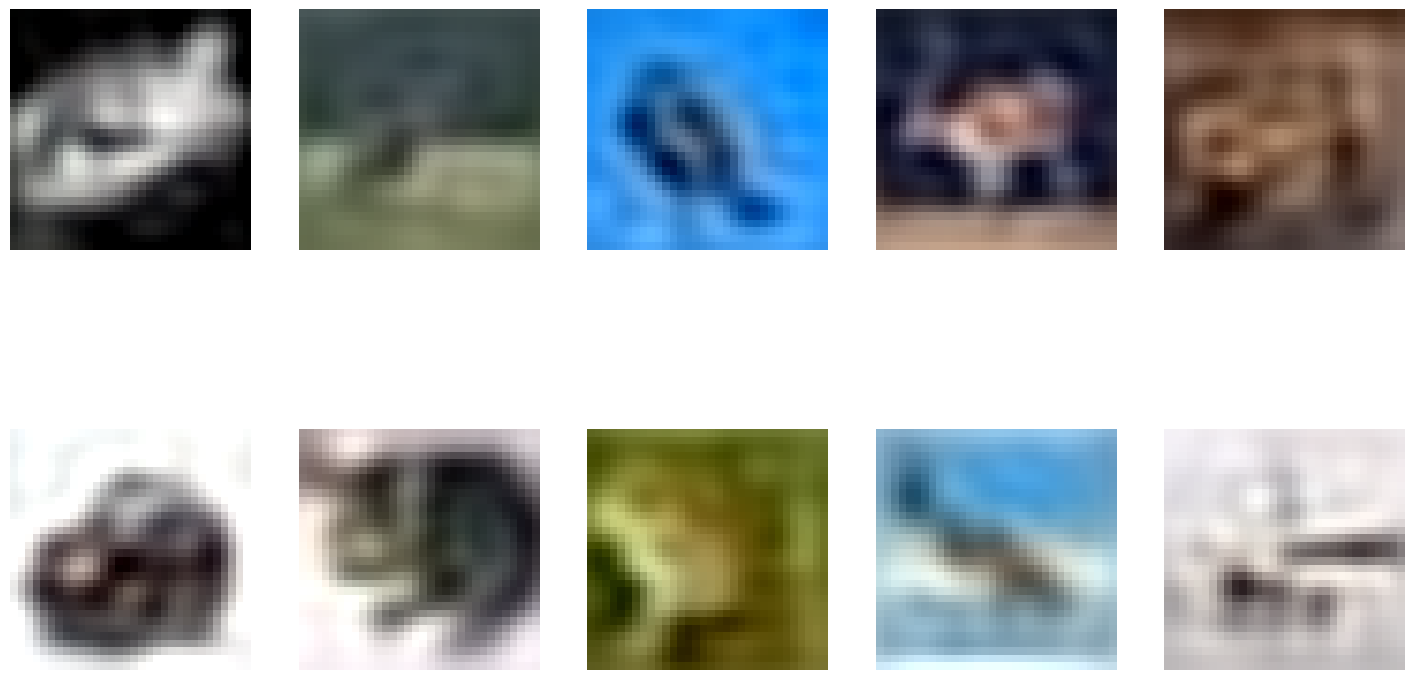

In [12]:
fig, axes = plt.subplots(2, 5, figsize=(18, 10))
for i, img_flat in enumerate(img_flats):
    #CHW形式にもどしてから軸を入れ替える
    img_reshape = img_flat.reshape(3, 32, 32).transpose(1, 2, 0)

    #0-1の範囲にクリップ(np.clip)
    img_final = np.clip(img_reshape, 0, 1)

    #可視化
    ax = axes[i // 5, i % 5]
    ax.imshow(img_final)
    ax.axis('off')


In [13]:
from sklearn.manifold import TSNE

selected_indices = []
#t-SNEのため、ラベルごとの画像のサンプリングを行う
for i in range(10):
    target_label = i
    #indicesはラベルがtarget_labelに合致しているかどうかをすべてについてチェックし、そのうち先頭500個のみ取り出す
    indices = np.where(label_list == target_label)[0][:500]
    selected_indices.append(indices)

# 全クラスのインデックスを一つの配列に統合
selected_indices = np.concatenate(selected_indices)

#X_pcaからそれぞれのラベルの画像を均等な枚数抽出
X_subset = X_pca[selected_indices]
label_subset = label_list[selected_indices]

#t-SNEを一度だけ実行
tsne = TSNE(n_components=2, perplexity=50, random_state=42)
X_tsne = tsne.fit_transform(X_subset)
X_tsne.shape

(5000, 2)

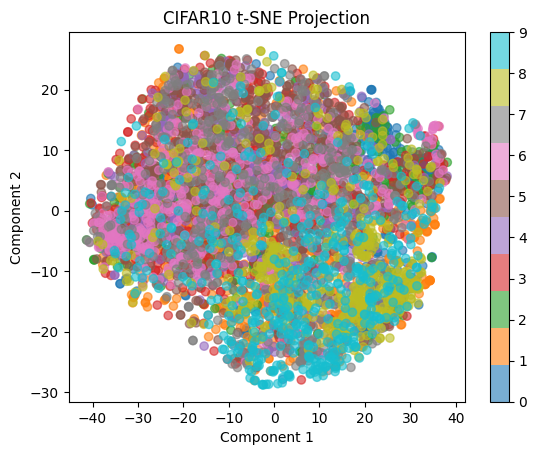

In [14]:
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1],
                      c=label_subset, cmap='tab10', alpha=0.6)
plt.colorbar(scatter, ticks=range(10))
plt.title("CIFAR10 t-SNE Projection")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()

In [32]:
#CNNの実装
class CIFAR10CNN(nn.Module):
    def __init__(self):
        super().__init__()

        #残差ブロックインスタンス
        self.res_block1 = SimpleResidualBlock(32)
        self.res_block2 = SimpleResidualBlock(64)
        self.res_block3 = SimpleResidualBlock(128)

        self.stem = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(128, 256, 3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)

        #マックスプーリング
        self.pool = nn.MaxPool2d(2)

        #ドロップアウト
        self.drop2d = nn.Dropout2d(0.2)
        self.drop = nn.Dropout(0.2)

        #MLP
        self.fc1 = nn.Linear(2048, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.bn1(self.stem(x)))
        x = self.drop2d(self.pool(self.res_block1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.drop2d(self.pool(self.res_block2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.drop2d(self.pool(self.res_block3(x)))

        x = x.view(-1, 2048)

        x = F.relu(self.drop(self.fc1(x)))
        x = self.fc2(x)

        return x

In [47]:
#残差ブロックの構築
class SimpleResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        # 2つの畳み込み層（サイズもチャネル数も変えない）
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(channels)

        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(channels)

    def forward(self, x):
        #入力をべつの変数に格納する
        identity = x
        out = self.bn2(self.conv2(F.relu(self.bn1(self.conv1(x)))))
        #格納していた別の変数を足してその後に活性化関数を適用させる
        out = out + identity
        out = F.relu(out)
        return out

In [34]:
#モデルの準備
model = CIFAR10CNN()

optimizer = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

#GPUに設定
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

CIFAR10CNN(
  (res_block1): SimpleResidualBlock(
    (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (res_block2): SimpleResidualBlock(
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (res_block3): SimpleResidualBlock(
    (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Con

In [41]:
#訓練ループ(早期終了込み)の構築
def training_loop(n_epochs, optimizer, model, loss_fn, train_loader, test_loader):
    loss_counter = 0
    loss_min = float('inf')
    for epoch in range(1, n_epochs + 1):
        total = 0
        correct = 0
        loss_train =  0.0
        model.train()
        for imgs, labels in train_loader:
            #imgsとlabelsをGPUに移す
            imgs = imgs.to(device=device)
            labels = labels.to(device=device)

            optimizer.zero_grad()
            outputs = model(imgs)

            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()

            #1回のループの損失を加算して訓練データの1エボックの損失の合計を出す
            loss_train += loss.item()
        with torch.no_grad():
            model.eval()
            loss_val = 0.0
            for imgs, labels in test_loader:
                imgs = imgs.to(device=device)
                labels = labels.to(device=device)
                outputs = model(imgs)
                loss = loss_fn(outputs, labels)

                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

                #テストデータも同様に1エボックごとの損失の合計を出す
                loss_val += loss.item()

            #早期終了を設定
            if loss_counter == 5:
                return
            elif loss_val >= loss_min:
                loss_counter += 1
            elif loss_counter == 0 or loss_val < loss_min:
                loss_min = loss_val
                loss_counter = 0

            accuracy = correct / total

        print(f"Epoch: {epoch}, Loss: {loss_train / len(train_loader)}")
        print(f"Accuracy: {accuracy}, Valloss: {loss_val / len(test_loader)}")


In [45]:
#訓練ループ(早期終了、lr_scheduler込み)の構築
def training_loop(n_epochs, optimizer, model, loss_fn, train_loader, test_loader):
    loss_counter = 0
    loss_min = float('inf')
    #schedulerは5エボックごとに学習率を0.1倍させる
    scheduler = lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)
    for epoch in range(1, n_epochs + 1):
        total = 0
        correct = 0
        loss_train =  0.0
        model.train()
        for imgs, labels in train_loader:
            #imgsとlabelsをGPUに移す
            imgs = imgs.to(device=device)
            labels = labels.to(device=device)

            optimizer.zero_grad()
            outputs = model(imgs)

            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()

            #1回のループの損失を加算して訓練データの1エボックの損失の合計を出す
            loss_train += loss.item()
        with torch.no_grad():
            model.eval()
            loss_val = 0.0
            for imgs, labels in test_loader:
                imgs = imgs.to(device=device)
                labels = labels.to(device=device)
                outputs = model(imgs)
                loss = loss_fn(outputs, labels)

                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

                #テストデータも同様に1エボックごとの損失の合計を出す
                loss_val += loss.item()

            #早期終了を設定
            if loss_counter == 5:
                return
            elif loss_val >= loss_min:
                loss_counter += 1
            elif loss_counter == 0 or loss_val < loss_min:
                loss_min = loss_val
                loss_counter = 0

            accuracy = correct / total
            #学習率の更新
            scheduler.step()

        print(f"Epoch: {epoch}, Loss: {loss_train / len(train_loader)}")
        print(f"Accuracy: {accuracy}, Valloss: {loss_val / len(test_loader)}")

In [36]:
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

In [38]:
cifar10 = datasets.CIFAR10(root='/content/', train=True, download=True, transform=transform)
cifar10_val = datasets.CIFAR10(root='/content/', train=False, download=True, transform=test_transform)
train_loader = DataLoader(cifar10, batch_size=1024, shuffle=True)
test_loader = DataLoader(cifar10_val, batch_size=1024, shuffle=True)

In [39]:
#1～10エボック目
training_loop(10, optimizer, model, loss_fn, train_loader, test_loader)

Epoch: 1, Loss: 2.018197400229318
Accuracy: 0.3692, Valloss: 1.6925123810768128
Epoch: 2, Loss: 1.7197703098764225
Accuracy: 0.4108, Valloss: 1.5839479804039
Epoch: 3, Loss: 1.5654450095429713
Accuracy: 0.51, Valloss: 1.3107035040855408
Epoch: 4, Loss: 1.4566208051175487
Accuracy: 0.5509, Valloss: 1.2149505376815797
Epoch: 5, Loss: 1.350135941894687
Accuracy: 0.5987, Valloss: 1.1046648025512695
Epoch: 6, Loss: 1.2466543888559147
Accuracy: 0.6026, Valloss: 1.0852195501327515
Epoch: 7, Loss: 1.175105880717842
Accuracy: 0.6505, Valloss: 0.9694844305515289
Epoch: 8, Loss: 1.1047537643082288
Accuracy: 0.6534, Valloss: 0.9910389423370362
Epoch: 9, Loss: 1.0413697921499914
Accuracy: 0.6968, Valloss: 0.8552886009216308
Epoch: 10, Loss: 0.9985360928944179
Accuracy: 0.7122, Valloss: 0.8050619661808014


In [40]:
#11～20エボック目
training_loop(10, optimizer, model, loss_fn, train_loader, test_loader)

Epoch: 1, Loss: 0.9557188226252186
Accuracy: 0.7312, Valloss: 0.7653374791145324
Epoch: 2, Loss: 0.913442577634539
Accuracy: 0.7433, Valloss: 0.7159749031066894
Epoch: 3, Loss: 0.8812170223313935
Accuracy: 0.7489, Valloss: 0.7042217969894409
Epoch: 4, Loss: 0.8480187532853107
Accuracy: 0.7464, Valloss: 0.7388835370540618
Epoch: 5, Loss: 0.8170945255123839
Accuracy: 0.7583, Valloss: 0.695115840435028
Epoch: 6, Loss: 0.792367413335917
Accuracy: 0.7581, Valloss: 0.6878243148326874
Epoch: 7, Loss: 0.777256693158831
Accuracy: 0.7879, Valloss: 0.6145292282104492
Epoch: 8, Loss: 0.7561804384601359
Accuracy: 0.7926, Valloss: 0.6022609591484069
Epoch: 9, Loss: 0.7329686916604334
Accuracy: 0.7884, Valloss: 0.6195222079753876
Epoch: 10, Loss: 0.7106843748871161
Accuracy: 0.7864, Valloss: 0.6268678367137909


In [42]:
#21～30エボック目(早期終了設定反映後)
training_loop(10, optimizer, model, loss_fn, train_loader, test_loader)

Epoch: 1, Loss: 0.6921500770413146
Accuracy: 0.8034, Valloss: 0.5764466345310211
Epoch: 2, Loss: 0.6842622173075773
Accuracy: 0.8059, Valloss: 0.5803724110126496
Epoch: 3, Loss: 0.6638020155381184
Accuracy: 0.8089, Valloss: 0.5677077174186707
Epoch: 4, Loss: 0.6551739573478699
Accuracy: 0.8244, Valloss: 0.5079534709453583
Epoch: 5, Loss: 0.634907531494997
Accuracy: 0.8128, Valloss: 0.552482295036316
Epoch: 6, Loss: 0.6260951197877223
Accuracy: 0.819, Valloss: 0.5378006279468537
Epoch: 7, Loss: 0.6145746659259407
Accuracy: 0.84, Valloss: 0.488416051864624
Epoch: 8, Loss: 0.5944951419927635
Accuracy: 0.8334, Valloss: 0.5100024461746215
Epoch: 9, Loss: 0.5868243806216181
Accuracy: 0.83, Valloss: 0.5044734597206115
Epoch: 10, Loss: 0.583079204267385
Accuracy: 0.8233, Valloss: 0.5277156084775925


In [46]:
#31～40エボック目(学習率調整反映後)
training_loop(10, optimizer, model, loss_fn, train_loader, test_loader)

Epoch: 1, Loss: 0.5709196292624181
Accuracy: 0.8349, Valloss: 0.4928059458732605
Epoch: 2, Loss: 0.5590262717130233
Accuracy: 0.8439, Valloss: 0.4808167576789856
Epoch: 3, Loss: 0.5574839431412366
Accuracy: 0.8285, Valloss: 0.5187717497348785
Epoch: 4, Loss: 0.5489094354668442
Accuracy: 0.8459, Valloss: 0.4674077033996582
Epoch: 5, Loss: 0.534872327532087
Accuracy: 0.8246, Valloss: 0.5346127629280091
Epoch: 6, Loss: 0.5016439940248217
Accuracy: 0.8578, Valloss: 0.42550262808799744
Epoch: 7, Loss: 0.4717925866039432
Accuracy: 0.8622, Valloss: 0.4192144930362701
Epoch: 8, Loss: 0.469385815518243
Accuracy: 0.8644, Valloss: 0.4126891016960144
Epoch: 9, Loss: 0.45685613094543925
Accuracy: 0.8635, Valloss: 0.41580391228199004
Epoch: 10, Loss: 0.45585986667749834
Accuracy: 0.8634, Valloss: 0.42004149556159975
